In [1]:
# INDIAN AIRLINE PRICING PROJECT

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Statistics
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [6]:
# Load dataset
df = pd.read_csv("Data_Train.csv")

# Preview dataset
print(df.head())

print("\nDataset Shape:")
print(df.shape)

       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897  
1    05:50         13:15   7h 25m     2 stops         No info   7662  
2    09:25  04:25 10 Jun      19h     2 stops         No info  13882  
3    18:05         23:30   5h 25m      1 stop         No info   6218  
4    16:50         21:35   4h 45m      1 stop         No info  13302  

Dataset Shape:
(10683, 11)


In [7]:
# Show columns
print("Columns:")
print(df.columns)

# Dataset info
print("\nDataset Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Columns:
Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB
None

Missing Values:
Airline         

In [8]:
# DATA CLEANING

# Remove missing values
df = df.dropna()

# Create route identifier
df["Route_ID"] = df["Source"] + " → " + df["Destination"]

# Check unique routes
print("Unique routes:")
print(df["Route_ID"].nunique())

# Preview routes
print("\nSample Routes:")
print(df["Route_ID"].unique()[:10])

Unique routes:
6

Sample Routes:
['Banglore → New Delhi' 'Kolkata → Banglore' 'Delhi → Cochin'
 'Chennai → Kolkata' 'Banglore → Delhi' 'Mumbai → Hyderabad']


In [9]:
# COMPETITION ANALYSIS

# Count number of airlines on each route
competition = (
    df.groupby("Route_ID")["Airline"]
    .nunique()
    .reset_index()
)

competition.columns = ["Route_ID", "Num_Airlines"]

# Merge back into main dataframe
df = df.merge(competition, on="Route_ID", how="left")

# Create competition category
def classify_market(n):
    if n == 1:
        return "Monopoly"
    elif n == 2:
        return "Duopoly"
    else:
        return "Competitive"

df["Market_Type"] = df["Num_Airlines"].apply(classify_market)

# Preview
print(df[["Route_ID", "Num_Airlines", "Market_Type"]].head())

               Route_ID  Num_Airlines  Market_Type
0  Banglore → New Delhi             9  Competitive
1    Kolkata → Banglore             7  Competitive
2        Delhi → Cochin            10  Competitive
3    Kolkata → Banglore             7  Competitive
4  Banglore → New Delhi             9  Competitive


In [10]:
# PRICE COMPARISON

# Average prices
avg_prices = (
    df.groupby("Market_Type")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_prices)

Market_Type
Competitive    9087.214567
Name: Price, dtype: float64


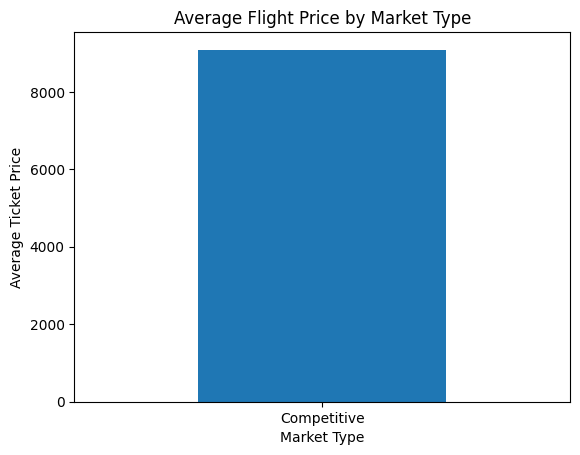

In [11]:
# VISUALIZATION

avg_prices.plot(kind="bar")

plt.title("Average Flight Price by Market Type")
plt.xlabel("Market Type")
plt.ylabel("Average Ticket Price")

plt.xticks(rotation=0)

plt.show()

In [14]:
# COMPETITION DISTRIBUTION

# Count airlines per route
route_comp = (
    df.groupby("Route_ID")["Airline"]
    .nunique()
    .reset_index()
)

route_comp.columns = ["Route_ID", "Num_Airlines"]

print(route_comp.sort_values(by="Num_Airlines"))

               Route_ID  Num_Airlines
2     Chennai → Kolkata             5
5    Mumbai → Hyderabad             6
4    Kolkata → Banglore             7
0      Banglore → Delhi             8
1  Banglore → New Delhi             9
3        Delhi → Cochin            10


In [15]:
# Merge competition count
df = df.merge(route_comp, on="Route_ID", how="left")

# Average price by competition level
competition_prices = (
    df.groupby("Num_Airlines")["Price"]
    .mean()
)

print(competition_prices)

Num_Airlines
5      4789.892388
6      5059.708752
7      9158.389411
8      5143.918577
9     11917.716738
10    10540.113536
Name: Price, dtype: float64


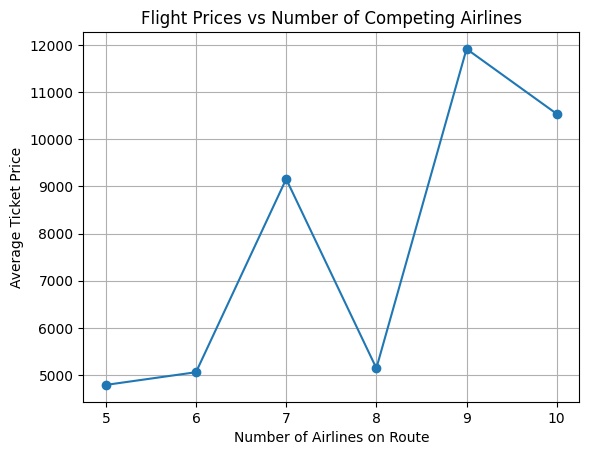

In [16]:
# PRICE VS COMPETITION

competition_prices.plot(marker='o')

plt.title("Flight Prices vs Number of Competing Airlines")
plt.xlabel("Number of Airlines on Route")
plt.ylabel("Average Ticket Price")

plt.grid(True)

plt.show()

In [17]:
# CLEAN TOTAL STOPS

# Convert stops into numbers
def clean_stops(x):
    if x == "non-stop":
        return 0
    else:
        return int(x.split(" ")[0])

df["Stops_Num"] = df["Total_Stops"].apply(clean_stops)

# Preview
print(df[["Total_Stops", "Stops_Num"]].head())

  Total_Stops  Stops_Num
0    non-stop          0
1     2 stops          2
2     2 stops          2
3      1 stop          1
4      1 stop          1


In [18]:
# CLEAN DURATION

def duration_to_minutes(duration):
    hours = 0
    minutes = 0

    if 'h' in duration:
        hours = int(duration.split('h')[0].strip())

    if 'm' in duration:
        minutes_part = duration.split('h')[-1].replace('m', '').strip()
        if minutes_part != '':
            minutes = int(minutes_part)

    return hours * 60 + minutes

df["Duration_Minutes"] = df["Duration"].apply(duration_to_minutes)

# Preview
print(df[["Duration", "Duration_Minutes"]].head())

  Duration  Duration_Minutes
0   2h 50m               170
1   7h 25m               445
2      19h              1140
3   5h 25m               325
4   4h 45m               285


In [19]:
# REGRESSION MODEL

# Define variables
X = df[["Num_Airlines", "Stops_Num", "Duration_Minutes"]]

# Add constant
X = sm.add_constant(X)

# Target variable
y = df["Price"]

# Run OLS regression
model = sm.OLS(y, X).fit()

# Show results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     2166.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        15:15:57   Log-Likelihood:            -1.0273e+05
No. Observations:               10682   AIC:                         2.055e+05
Df Residuals:                   10678   BIC:                         2.055e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             3581.9462    202.137  

In [20]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     2166.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        15:16:14   Log-Likelihood:            -1.0273e+05
No. Observations:               10682   AIC:                         2.055e+05
Df Residuals:                   10678   BIC:                         2.055e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             3581.9462    202.137     17.720      0.000    3185.721    3978.171
Num_Airlines       247.3727     25.436      9.725      0.000     197.514     297.231
Stops_Num         3141.9751     83.539     37.611      0.000    2978.222    3305.728
Duration_Minutes     1.2912      0.103     12.534      0.000       1.089       1.493
==============================================================================
Omnibus:                     8535.524   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           550174.755
Skew:                           3.355   Prob(JB):                         0.00
Kurtosis:                      37.512   Cond. No.                     4.78e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.78e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

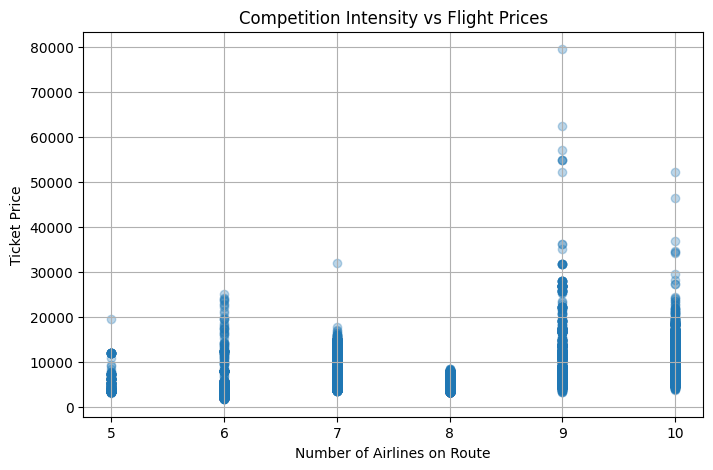

In [21]:
# SCATTER PLOT

plt.figure(figsize=(8,5))

plt.scatter(
    df["Num_Airlines"],
    df["Price"],
    alpha=0.3
)

plt.title("Competition Intensity vs Flight Prices")
plt.xlabel("Number of Airlines on Route")
plt.ylabel("Ticket Price")

plt.grid(True)

plt.show()

In [22]:
# CORRELATION MATRIX

corr = df[
    ["Price", "Num_Airlines", "Stops_Num", "Duration_Minutes"]
].corr()

print(corr)

                     Price  Num_Airlines  Stops_Num  Duration_Minutes
Price             1.000000      0.338940   0.603897          0.506480
Num_Airlines      0.338940      1.000000   0.463135          0.294553
Stops_Num         0.603897      0.463135   1.000000          0.738071
Duration_Minutes  0.506480      0.294553   0.738071          1.000000


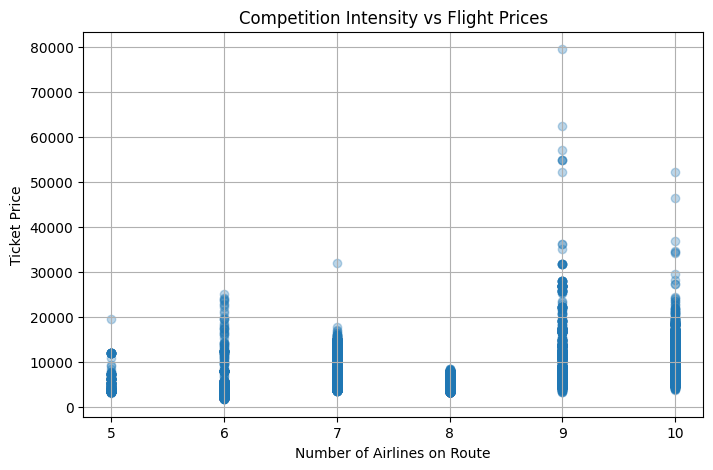

In [24]:


plt.figure(figsize=(8,5))

plt.scatter(
    df["Num_Airlines"],
    df["Price"],
    alpha=0.3
)

plt.title("Competition Intensity vs Flight Prices")
plt.xlabel("Number of Airlines on Route")
plt.ylabel("Ticket Price")

plt.grid(True)

# SAVE BEFORE SHOW
plt.savefig(
    "competition_vs_price.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()